In [1]:
import pandas as pd
import numpy as np

customers = pd.read_csv("../../data/raw/customers.csv") 
orders = pd.read_csv("../../data/raw/orders.csv")
order_items = pd.read_csv("../../data/raw/order_items.csv")
products = pd.read_csv("../../data/raw/products.csv")

print(customers.head())
print(orders.head())
print(order_items.head())
print(products.head())

   customer_id name gender  age city signup_date
0            1  김수민      F   19   광주  2024-08-21
1            2  김정호      F   32   대구  2026-01-04
2            3  이경수      F   61   성남  2024-08-14
3            4  조영호      F   55   울산  2026-06-15
4            5  이예원      F   19   부산  2024-11-15
   order_id  customer_id  order_date payment_method order_status
0         1          123  2026-07-09           card    completed
1         2           77  2025-09-24      naver_pay    cancelled
2         3          138  2026-01-21  bank_transfer    cancelled
3         4           57  2026-04-03      kakao_pay    cancelled
4         5          125  2026-02-22           card    cancelled
   order_item_id  order_id  product_id  quantity  unit_price
0              1         1         100         3      102000
1              2         1          87         5       25000
2              3         1           7         3      142000
3              4         1           9         3      193000
4          

3. matplotlib의 기본 구조를 이해합니다

In [2]:
from matplotlib import font_manager

installed_fonts = {
    font.name
    for font in font_manager.fontManager.ttflist
}

font_candidates = [
    "Malgun Gothic",
    "AppleGothic",
    "Apple SD Gothic Neo",
    "Noto Sans CJK KR",
    "NanumGothic",
]

In [4]:
import matplotlib.pyplot as plt

In [5]:
korean_font = next(
    (name for name in font_candidates if name in installed_fonts), None
)

print("선택된 한글 폰트 :", korean_font)

if korean_font:
    plt.rcParams["font.family"] = korean_font
plt.rcParams["axes.unicode_minus"] = False

선택된 한글 폰트 : Malgun Gothic


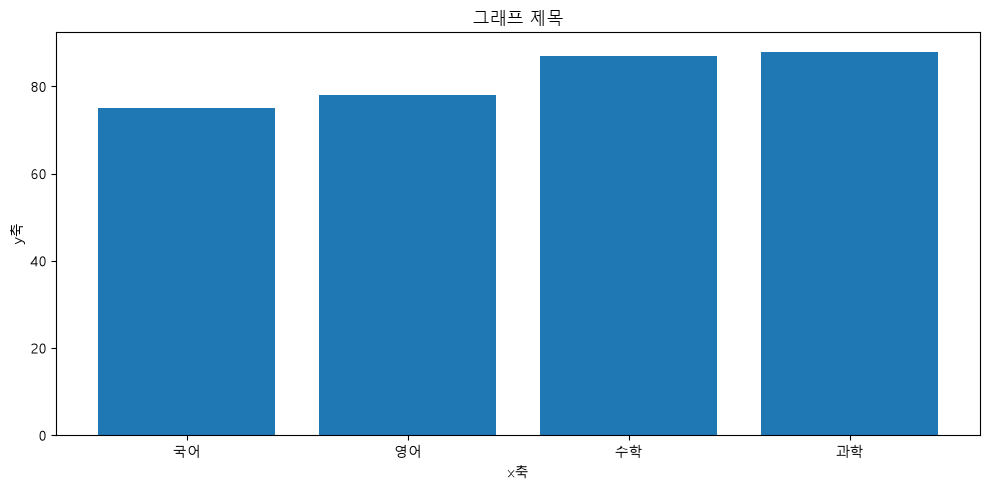

In [6]:
import matplotlib.pyplot as plt

x_data=["국어", "영어", "수학", "과학"]
y_data = [75, 78, 87, 88]


fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(x_data, y_data)

ax.set_title("그래프 제목")

ax.set_xlabel("x축")

ax.set_ylabel("y축")

ax.set_ylim(bottom=0)

fig.tight_layout()

fig.savefig(
    "graph.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [7]:
orders.head()
orders["order_date"] = pd.to_datetime(orders["order_date"], errors="raise")
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        300 non-null    int64         
 1   customer_id     300 non-null    int64         
 2   order_date      300 non-null    datetime64[us]
 3   payment_method  300 non-null    str           
 4   order_status    300 non-null    str           
dtypes: datetime64[us](1), int64(2), str(2)
memory usage: 11.8 KB


In [8]:
from pathlib import Path

project_root = Path.cwd().parents[1]
processed_dir = project_root / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

In [9]:
products_cleaned = pd.read_csv("https://raw.githubusercontent.com/GilbertMoon/llm-data-analysis-course/refs/heads/main/data/processed/products_clean.csv")

products_cleaned.to_csv(
    processed_dir / "products_clean.csv",
    index=False,
    encoding="utf-8-sig",
)

products_cleaned.head()

,product_id,product_name,category,price
0,1,도서 상품 001,도서,61000.0
1,2,전자기기 상품 002,전자기기,154000.0
2,3,뷰티 상품 003,전자기기,48000.0
3,4,패션 상품 004,패션,33000.0
4,5,스포츠 상품 005,스포츠,73000.0


In [10]:
df_visualization = pd.read_csv("https://raw.githubusercontent.com/GilbertMoon/llm-data-analysis-course/refs/heads/main/data/processed/visualization.csv")

df_visualization.to_csv(
    processed_dir / "visualization.csv",
    index=False,
    encoding="utf-8-sig",
)

df_visualization.head()

,order_item_id,order_id,customer_id,product_id,order_date,order_month,order_dayofweek,payment_method,order_status,gender,...,product_name,category,price,quantity,unit_price,line_total,order_match,product_match,customer_match,merge_valid
0,1,1,144.0,39,2026-07-12,2026-07,Sunday,naver_pay,completed,F,...,뷰티 상품 039,뷰티,172000.0,2.0,172000.0,344000.0,True,True,True,True
1,2,2,149.0,26,2025-10-02,2025-10,Thursday,kakao_pay,completed,M,...,뷰티 상품 026,뷰티,79000.0,4.0,79000.0,316000.0,True,True,True,True
2,3,2,149.0,46,2025-10-02,2025-10,Thursday,kakao_pay,completed,M,...,생활용품 상품 046,생활용품,87000.0,3.0,87000.0,261000.0,True,True,True,True
3,4,2,149.0,80,2025-10-02,2025-10,Thursday,kakao_pay,completed,M,...,패션 상품 080,패션,187000.0,1.0,187000.0,187000.0,True,True,True,True
4,5,2,149.0,91,2025-10-02,2025-10,Thursday,kakao_pay,completed,M,...,전자기기 상품 091,전자기기,125000.0,5.0,125000.0,625000.0,True,True,True,True


In [11]:
# products_cleaned는 위 셀에서 불러오고 저장했습니다.

In [12]:
# df_visualization은 위 셀에서 불러오고 저장했습니다.

In [13]:
df_visualization = df_visualization.dropna()
df_visualization.isna().sum().sum()

np.int64(0)

In [14]:
category_sales = df_visualization.groupby("category", dropna = False, as_index=False).agg(
    total_amount = ("line_total", sum),
    total_quantity=("quantity", sum)
).sort_values("total_amount", ascending=False)

category_sales

,category,total_amount,total_quantity
9,패션,63322000.0,532.0
6,식품,45972000.0,384.0
8,전자기기,34218000.0,280.0
0,도서,27876000.0,272.0
2,뷰티,26467000.0,268.0
5,스포츠,20468000.0,253.0
4,생활용품,13835000.0,204.0
3,생활 용품,3224000.0,26.0
1,뷰 티,1026000.0,19.0
7,전자 기기,252000.0,12.0


(0.0, 66488100.0)

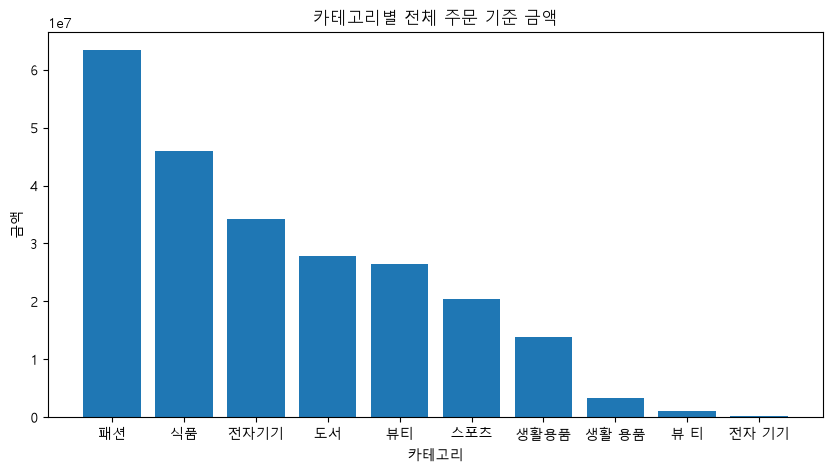

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    category_sales["category"],
    category_sales["total_amount"],
)

ax.set_title("카테고리별 전체 주문 기준 금액")
ax.set_xlabel("카테고리")
ax.set_ylabel("금액")
ax.set_ylim(bottom=0)

In [16]:
monthly_sales = df_visualization.groupby(df_visualization["order_month"]).agg(
    total_amount = ("line_total", "sum"),
    order_count = ("order_id", "nunique")
).sort_index()

monthly_sales

,total_amount,order_count
order_month,,
2025-07,13389000.0,18
2025-08,31736000.0,24
2025-09,12278000.0,12
2025-10,16352000.0,22
2025-11,12738000.0,22
2025-12,15684000.0,23
2026-01,18132000.0,25
2026-02,13582000.0,18
2026-03,13701000.0,22


In [18]:
monthly_sales = (
    df_visualization
    .groupby("order_month")
    .agg(
        total_amount=("line_total", "sum"),
        order_count=("order_id", "nunique"),
    )
    .sort_index()
    .reset_index()
)

monthly_sales

,order_month,total_amount,order_count
0,2025-07,13389000.0,18
1,2025-08,31736000.0,24
2,2025-09,12278000.0,12
3,2025-10,16352000.0,22
4,2025-11,12738000.0,22
5,2025-12,15684000.0,23
6,2026-01,18132000.0,25
7,2026-02,13582000.0,18
8,2026-03,13701000.0,22
9,2026-04,19700000.0,24


Text(0, 0.5, '금액')

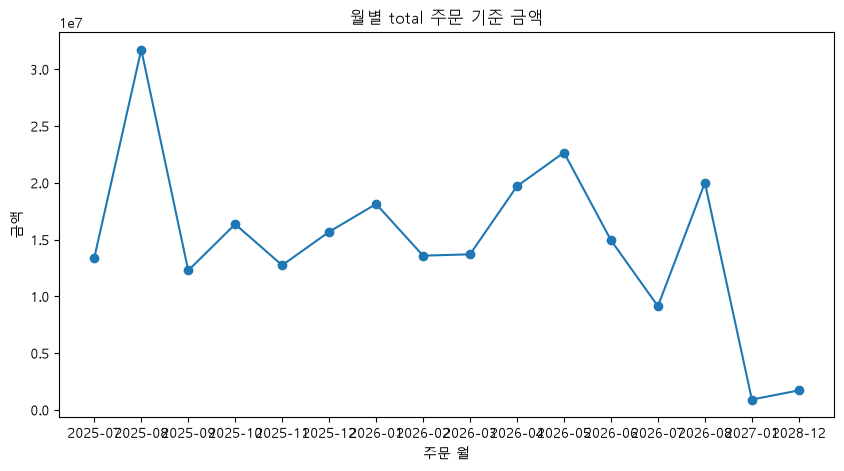

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    monthly_sales["order_month"],
    monthly_sales["total_amount"],
    marker="o",
)

ax.set_title("월별 total 주문 기준 금액")
ax.set_xlabel("주문 월")
ax.set_ylabel("금액")

Text(0, 0.5, '상품 수')

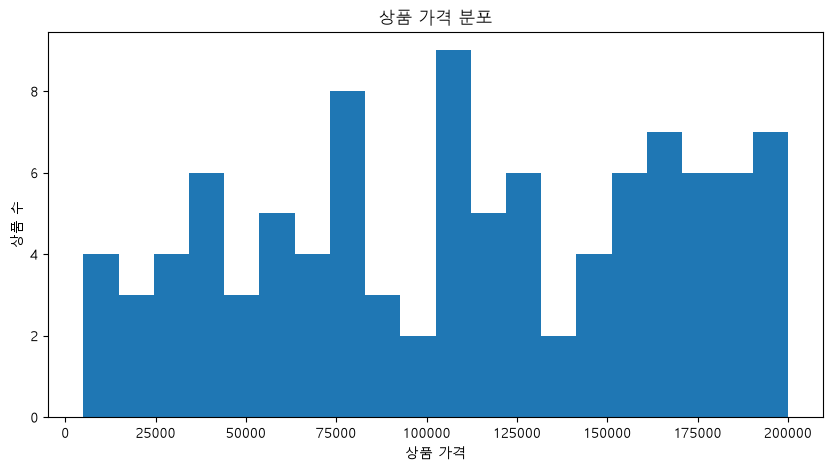

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    products["price"],
    bins=20,
)

ax.set_title("상품 가격 분포")

ax.set_xlabel("상품 가격")

ax.set_ylabel("상품 수")

In [22]:
products_sales = df_visualization.groupby("products_id", as_index=False).agg(
    total_quantity = ("quantity", "sum"),
    total_
)

products_quantity

SyntaxError: positional argument follows keyword argument (1086468338.py, line 4)

NameError: name 'product_sales' is not defined

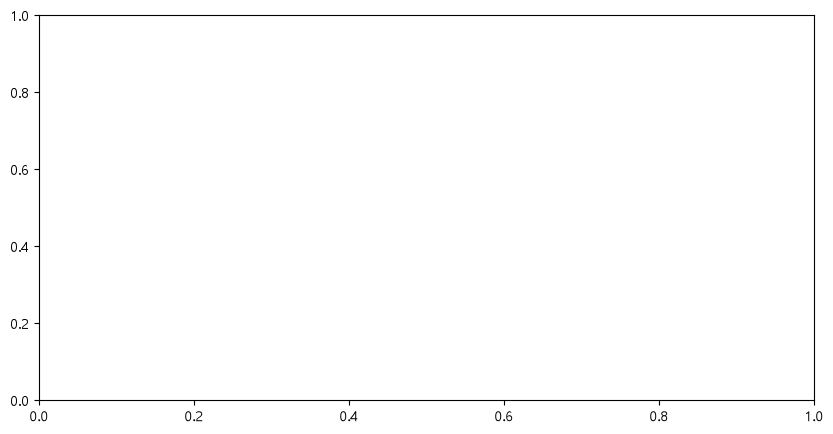

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(
    product_sales["price"],
    product_sales["completed_quantity"],
    alpha=0.6,
)

ax.set_title("상품 가격과 completed 판매 수량")
ax.set_xlabel("상품 가격")
ax.set_ylabel("completed 판매 수량")